Deep Learning and Neural Networks with Python and PyTorch
---

- I've created this notebook while following the lectures from __Sentdex Youtube Tutorial__ on __[Pytorch - Deep learning w/ Python](https://www.youtube.com/playlist?list=PLQVvvaa0QuDdeMyHEYc0gxFpYwHY2Qfdh)__
- The dataset used for this tutorial is the MNIST handwritten digits downladed using PyTorch inbuilt functions.

### 1. Introduction

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision import transforms, datasets

import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim

import os 
import cv2
from tqdm import tqdm

In [2]:
x = torch.tensor([8, 10])
y = torch.tensor([2, 3])

print(x * y)

tensor([16, 30])


In [3]:
x = torch.zeros([2, 5])
print(x)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])


In [4]:
x.shape

torch.Size([2, 5])

In [5]:
y = torch.rand(2, 3)

In [6]:
y

tensor([[0.4131, 0.5370, 0.7398],
        [0.6916, 0.2308, 0.3797]])

In [7]:
y.view([1, 6])

tensor([[0.4131, 0.5370, 0.7398, 0.6916, 0.2308, 0.3797]])

In [8]:
y

tensor([[0.4131, 0.5370, 0.7398],
        [0.6916, 0.2308, 0.3797]])

In [9]:
y = y.view([1, 6])

In [10]:
y

tensor([[0.4131, 0.5370, 0.7398, 0.6916, 0.2308, 0.3797]])

### 2. Data

In [11]:
train = datasets.MNIST("", train = True, download = True, transform = transforms.Compose([transforms.ToTensor()]))

test = datasets.MNIST("", train = False, download = True, transform = transforms.Compose([transforms.ToTensor()]))

  0%|          | 0/9912422 [00:00<?, ?it/s]

9920512it [00:01, 4968539.26it/s]                             


Extracting MNIST/raw/train-images-idx3-ubyte.gz to MNIST/raw


32768it [00:00, 402283.51it/s]
  2%|▏         | 40960/1648877 [00:00<00:04, 399539.27it/s]

Extracting MNIST/raw/train-labels-idx1-ubyte.gz to MNIST/raw


1654784it [00:00, 1440019.41it/s]                             
8192it [00:00, 176142.36it/s]


Extracting MNIST/raw/t10k-images-idx3-ubyte.gz to MNIST/raw
Extracting MNIST/raw/t10k-labels-idx1-ubyte.gz to MNIST/raw
Processing...
Done!


In [13]:
trainset = torch.utils.data.DataLoader(train, batch_size = 10, shuffle = True)

testset = torch.utils.data.DataLoader(test, batch_size = 10, shuffle = True)

In [15]:
for data in trainset:
    print(data)
    break

[tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0

In [16]:
x, y = data[0][0], data[1][0]
print(y)

tensor(1)


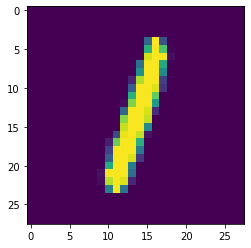

In [21]:
plt.imshow(x.view(28, 28))
plt.show()

In [25]:
total = 0
counter_dict = {0:0, 1:0, 2:0, 3:0, 4:0, 5:0, 6:0, 7:0, 8:0, 9:0}
for data in trainset:
    xs, ys = data
    for y in ys:
        counter_dict[int(y)] += 1
        total += 1
        
print(counter_dict)        
print(total)   

{0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}
60000


In [26]:
for i in counter_dict:
    print(f"{i}: {counter_dict[i]/total}")

0: 0.09871666666666666
1: 0.11236666666666667
2: 0.0993
3: 0.10218333333333333
4: 0.09736666666666667
5: 0.09035
6: 0.09863333333333334
7: 0.10441666666666667
8: 0.09751666666666667
9: 0.09915


### 3. Building Our Neural Network

In [27]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 10)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return F.log_softmax(x, dim = 1)

In [28]:
net = Net()
print(net)

Net(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=10, bias=True)
)


In [30]:
X = torch.rand(28, 28)
X = X.view(1, 28*28)

output = net(X)
print(output)

tensor([[-2.3849, -2.3555, -2.1668, -2.3636, -2.3710, -2.2506, -2.1885, -2.4228,
         -2.3032, -2.2537]], grad_fn=<LogSoftmaxBackward>)


### 4. Training Model

In [36]:
optimizer = optim.Adam(net.parameters(), lr = 0.001)

EPOCHS = 3

for epoch in range(EPOCHS):
    for data in trainset:
        X, y = data
        net.zero_grad()
        output = net(X.view(-1, 28*28))
        loss = F.nll_loss(output, y)
        loss.backward()
        optimizer.step()
    print(loss)

tensor(0.7134, grad_fn=<NllLossBackward>)
tensor(0.0123, grad_fn=<NllLossBackward>)
tensor(0.2049, grad_fn=<NllLossBackward>)


In [48]:
correct = 0
total = 0

with torch.no_grad():
    for data in trainset:
        X, y = data
        output = net(X.view(-1, 28*28))
        for idx, i in enumerate(output):
            if torch.argmax(i) == y[idx]:
                correct += 1
            total += 1
            
print("Accuracy: ", round(correct/total, 3))

Accuracy:  0.977


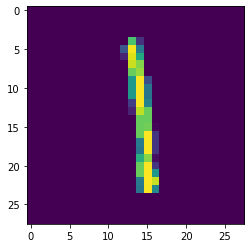

In [50]:
plt.imshow(X[0][0].view(28, 28))
plt.show()

In [51]:
print(torch.argmax(net(X[0].view(-1, 784))[0]))

tensor(1)
